Критическая область: G > 1.6449
Статистика критерия: 0.9289
Нет достаточных оснований отвергнуть H0


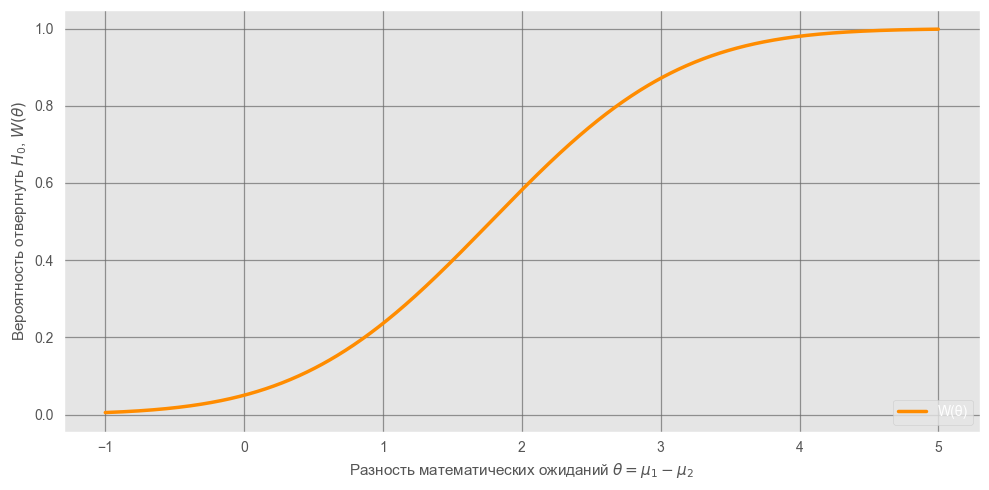

In [6]:
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats as stats

np.random.seed(52)
plt.style.use("ggplot")

group_a = np.array([-1.11, -6.10, 2.42], dtype=float)
group_b = np.array([-2.29, -2.91], dtype=float)

var_a = 2
var_b = 1
alpha = 0.05

n_a, n_b = group_a.size, group_b.size
avg_a, avg_b = group_a.mean(), group_b.mean()

standard_error = (var_a / n_a + var_b / n_b) ** 0.5
test_stat = (avg_a - avg_b) / standard_error

z_critical = stats.norm.ppf(q=1 - alpha)

print(f"Критическая область: G > {z_critical:.4f}")
print(f"Статистика критерия: {test_stat:.4f}")

if test_stat < z_critical:
    print("Нет достаточных оснований отвергнуть H0")
else:
    print("H0 отвергается в пользу H1")

theta_grid = np.linspace(-1.0, 5.0, 1000)

critical_border = stats.norm(loc=0, scale=standard_error).ppf(1 - alpha)
power_curve = 1 - stats.norm(loc=theta_grid, scale=standard_error).cdf(critical_border)

observed_difference = avg_a - avg_b
observed_power = 1 - stats.norm(
    loc=observed_difference,
    scale=standard_error
).cdf(critical_border)

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(
    theta_grid,
    power_curve,
    color="darkorange",
    linewidth=2.5,
    label="W(θ)"
)

ax.set_xlabel(r"Разность математических ожиданий $\theta = \mu_1 - \mu_2$", fontsize=11)
ax.set_ylabel(r"Вероятность отвергнуть $H_0$, $W(\theta)$", fontsize=11)
ax.grid(True, color="dimgray", alpha=0.7, linewidth=0.9)
ax.legend(loc="lower right", fontsize=10)

plt.tight_layout()
plt.show()